#  Analyse Exploratoire - Campagne Marketing Bancaire

**Objectif** : Comprendre les facteurs influençant la souscription à un dépôt à terme lors d'une campagne de télémarketing.

**Dataset** : 41 188 clients d'une banque portugaise (2008-2010)

**Variable cible** : `y` (yes = client a souscrit, no = client n'a pas souscrit)

---

## Plan d'analyse

1. Vue d'ensemble des données
2. Analyse de la variable cible
3. Profil des clients (âge, profession, éducation, situation)
4. Facteurs comportementaux
5. Corrélations
6. Insights métier

In [19]:
# Import des bibliothèques
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Configuration graphiques
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

# Création du dossier pour sauvegarder les graphiques
os.makedirs('../05_Resultats/plots', exist_ok=True)

import warnings
warnings.filterwarnings('ignore')

---
## 1. Chargement des données

In [22]:
# Chargement du dataset
df = pd.read_csv('../01_Donnees/raw/bank-additional-full.csv', sep=';')

print(f"Nombre de lignes : {len(df):,}")
print(f"Nombre de colonnes : {df.shape[1]}")

Nombre de lignes : 41,188
Nombre de colonnes : 21


In [3]:
# Aperçu des premières lignes
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


---
## 2. Vue d'ensemble des données

In [23]:
# Informations sur les types de données
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [24]:
# Statistiques descriptives des variables numériques
df.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


In [25]:
# Vérification des valeurs manquantes
missing = df.isnull().sum()
print("Valeurs manquantes par colonne :")
print(missing[missing > 0])

# Note : 'unknown' est encodé comme valeur, pas comme NaN
print(f"\nValeurs 'unknown' dans les colonnes catégorielles :")
for col in df.select_dtypes(include='object').columns:
    unknown_count = (df[col] == 'unknown').sum()
    if unknown_count > 0:
        print(f"{col}: {unknown_count} ({unknown_count/len(df)*100:.1f}%)")

Valeurs manquantes par colonne :
Series([], dtype: int64)

Valeurs 'unknown' dans les colonnes catégorielles :
job: 330 (0.8%)
marital: 80 (0.2%)
education: 1731 (4.2%)
default: 8597 (20.9%)
housing: 990 (2.4%)
loan: 990 (2.4%)


**Observation** : Pas de valeurs manquantes au sens strict, mais beaucoup de valeurs `unknown` dans certaines colonnes (job, education, etc.).

---
## 3. Analyse de la variable cible

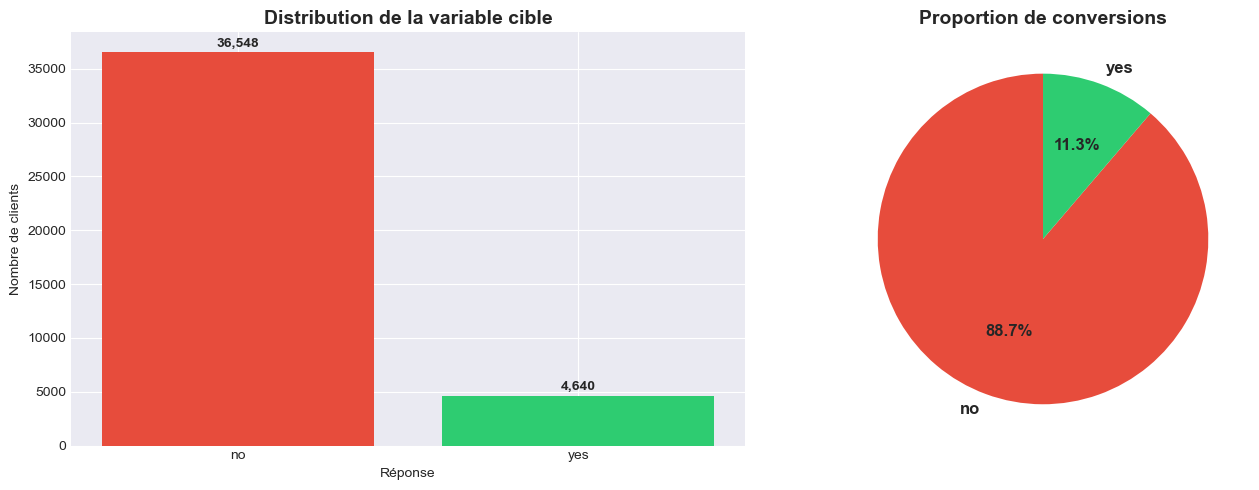

Taux de conversion : 11.27%


In [26]:
# Distribution de la variable cible
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Comptage
target_counts = df['y'].value_counts()
ax[0].bar(target_counts.index, target_counts.values, color=['#e74c3c', '#2ecc71'])
ax[0].set_title('Distribution de la variable cible', fontsize=14, fontweight='bold')
ax[0].set_xlabel('Réponse')
ax[0].set_ylabel('Nombre de clients')
for i, v in enumerate(target_counts.values):
    ax[0].text(i, v + 500, f'{v:,}', ha='center', fontweight='bold')

# Pourcentage
target_pct = df['y'].value_counts(normalize=True) * 100
colors = ['#e74c3c', '#2ecc71']
ax[1].pie(target_pct.values, labels=target_pct.index, autopct='%1.1f%%', 
          startangle=90, colors=colors, textprops={'fontsize': 12, 'fontweight': 'bold'})
ax[1].set_title('Proportion de conversions', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('../05_Resultats/plots/01_distribution_cible.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Taux de conversion : {target_pct['yes']:.2f}%")

**Insight métier** : Seulement 11% de conversion → classe très déséquilibrée. Cela signifie que la majorité des clients ne souscrivent pas. Un bon modèle devra gérer ce déséquilibre.

---
## 4. Analyse par âge

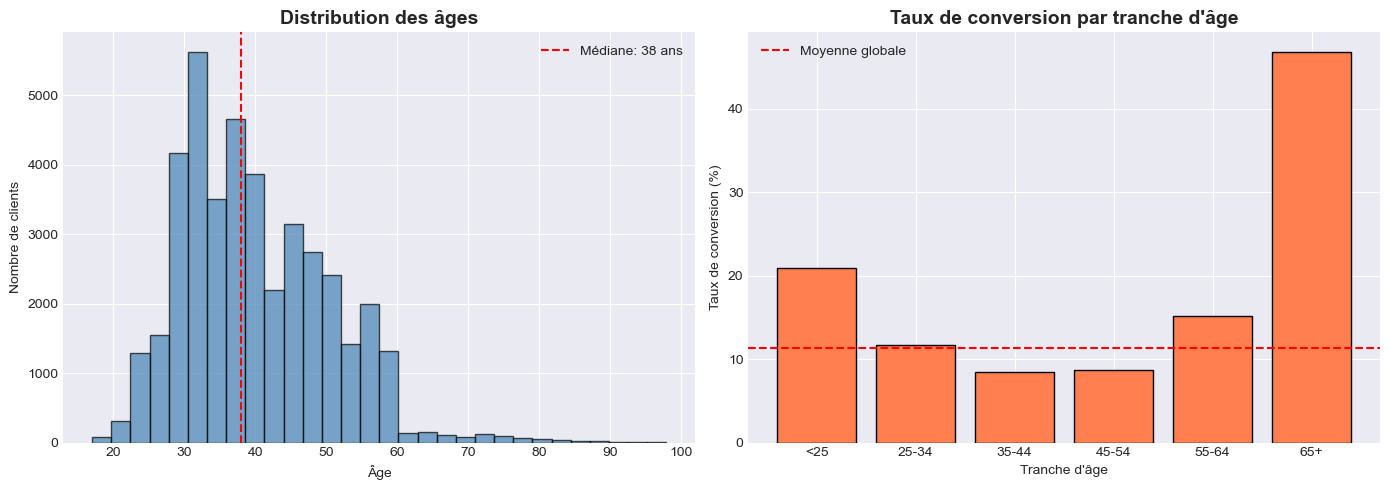

In [27]:
# Distribution de l'âge
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Histogramme global
ax[0].hist(df['age'], bins=30, color='steelblue', edgecolor='black', alpha=0.7)
ax[0].set_title('Distribution des âges', fontsize=14, fontweight='bold')
ax[0].set_xlabel('Âge')
ax[0].set_ylabel('Nombre de clients')
ax[0].axvline(df['age'].median(), color='red', linestyle='--', label=f'Médiane: {df["age"].median():.0f} ans')
ax[0].legend()

# Taux de conversion par tranche d'âge
age_bins = [0, 25, 35, 45, 55, 65, 100]
age_labels = ['<25', '25-34', '35-44', '45-54', '55-64', '65+']
df['age_group'] = pd.cut(df['age'], bins=age_bins, labels=age_labels)

conversion_by_age = df.groupby('age_group')['y'].apply(lambda x: (x == 'yes').sum() / len(x) * 100)
ax[1].bar(conversion_by_age.index, conversion_by_age.values, color='coral', edgecolor='black')
ax[1].set_title('Taux de conversion par tranche d\'âge', fontsize=14, fontweight='bold')
ax[1].set_xlabel('Tranche d\'âge')
ax[1].set_ylabel('Taux de conversion (%)')
ax[1].axhline(11.3, color='red', linestyle='--', label='Moyenne globale')
ax[1].legend()

plt.tight_layout()
plt.savefig('../05_Resultats/plots/02_conversion_age.png', dpi=150, bbox_inches='tight')
plt.show()

**Insight métier** : Les jeunes (<25 ans) et les seniors (65+) ont un meilleur taux de conversion. Les 35-54 ans (actifs) sont moins réceptifs.

---
## 5. Analyse par profession

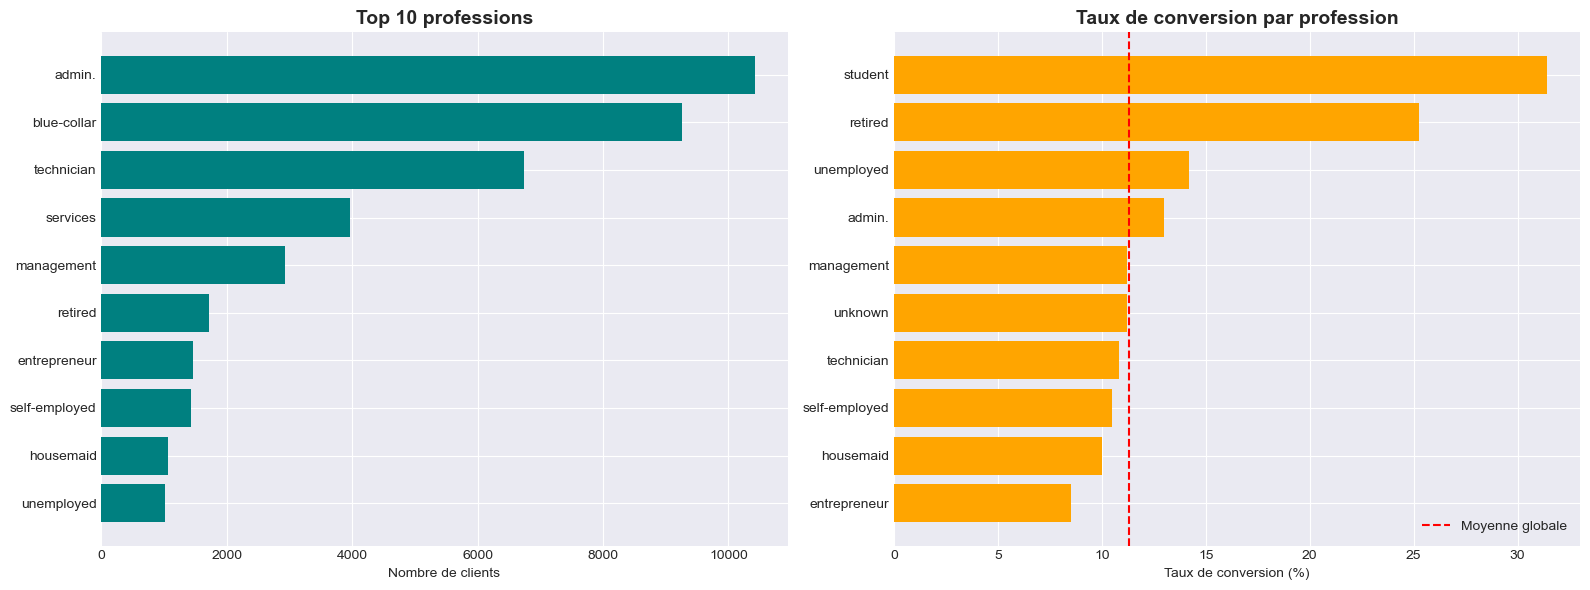

In [28]:
# Top 10 professions
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Répartition des professions
job_counts = df['job'].value_counts().head(10)
ax[0].barh(job_counts.index, job_counts.values, color='teal')
ax[0].set_title('Top 10 professions', fontsize=14, fontweight='bold')
ax[0].set_xlabel('Nombre de clients')
ax[0].invert_yaxis()

# Taux de conversion par profession
conversion_by_job = df.groupby('job')['y'].apply(lambda x: (x == 'yes').sum() / len(x) * 100).sort_values(ascending=False).head(10)
ax[1].barh(conversion_by_job.index, conversion_by_job.values, color='orange')
ax[1].set_title('Taux de conversion par profession', fontsize=14, fontweight='bold')
ax[1].set_xlabel('Taux de conversion (%)')
ax[1].axvline(11.3, color='red', linestyle='--', label='Moyenne globale')
ax[1].invert_yaxis()
ax[1].legend()

plt.tight_layout()
plt.savefig('../05_Resultats/plots/03_conversion_profession.png', dpi=150, bbox_inches='tight')
plt.show()

**Insight métier** : Les étudiants et retraités ont un taux de conversion nettement supérieur à la moyenne. Les cols bleus (blue-collar) et services sont moins réceptifs.

---
## 6. Analyse par niveau d'éducation

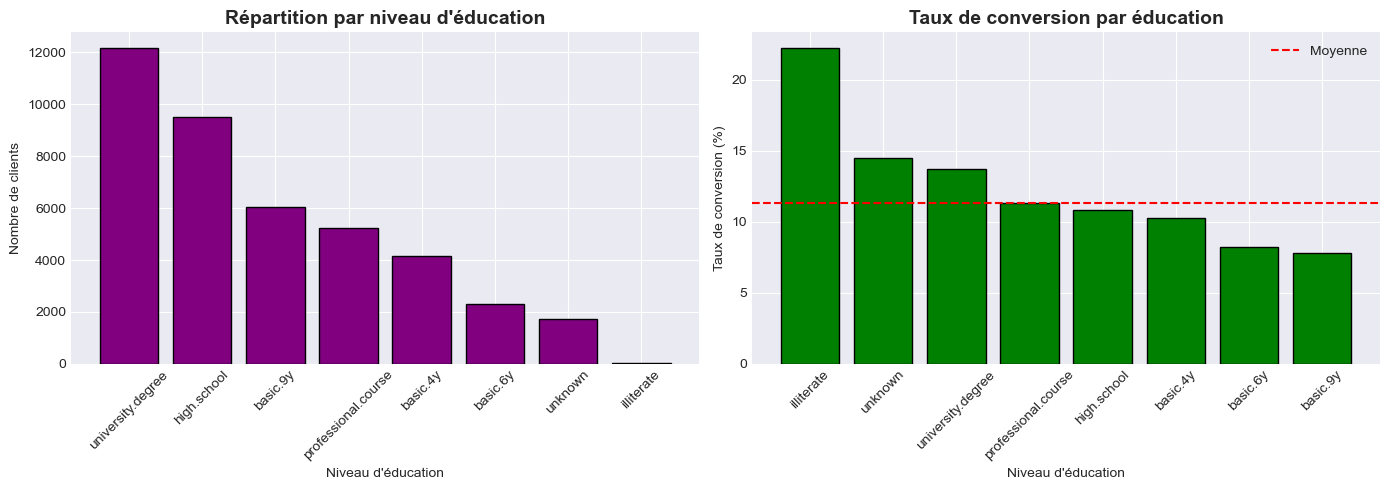

In [29]:
# Niveau d'éducation et conversion
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Répartition
education_counts = df['education'].value_counts()
ax[0].bar(education_counts.index, education_counts.values, color='purple', edgecolor='black')
ax[0].set_title('Répartition par niveau d\'éducation', fontsize=14, fontweight='bold')
ax[0].set_xlabel('Niveau d\'éducation')
ax[0].set_ylabel('Nombre de clients')
ax[0].tick_params(axis='x', rotation=45)

# Taux de conversion
conversion_by_edu = df.groupby('education')['y'].apply(lambda x: (x == 'yes').sum() / len(x) * 100).sort_values(ascending=False)
ax[1].bar(conversion_by_edu.index, conversion_by_edu.values, color='green', edgecolor='black')
ax[1].set_title('Taux de conversion par éducation', fontsize=14, fontweight='bold')
ax[1].set_xlabel('Niveau d\'éducation')
ax[1].set_ylabel('Taux de conversion (%)')
ax[1].axhline(11.3, color='red', linestyle='--', label='Moyenne')
ax[1].tick_params(axis='x', rotation=45)
ax[1].legend()

plt.tight_layout()
plt.savefig('../05_Resultats/plots/04_conversion_education.png', dpi=150, bbox_inches='tight')
plt.show()

**Insight métier** : Les personnes illitérées ont paradoxalement un taux de conversion élevé (petit échantillon). Les diplômés universitaires convertissent mieux que la moyenne.

---
## 7. Analyse par situation matrimoniale

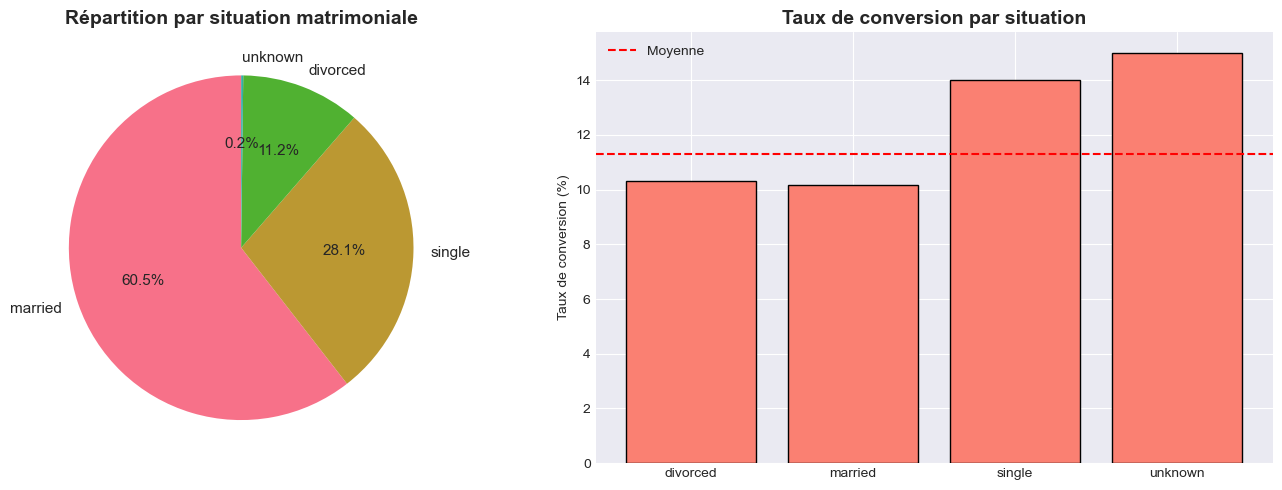

In [30]:
# Situation matrimoniale
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Répartition
marital_counts = df['marital'].value_counts()
ax[0].pie(marital_counts.values, labels=marital_counts.index, autopct='%1.1f%%', 
          startangle=90, textprops={'fontsize': 11})
ax[0].set_title('Répartition par situation matrimoniale', fontsize=14, fontweight='bold')

# Taux de conversion
conversion_by_marital = df.groupby('marital')['y'].apply(lambda x: (x == 'yes').sum() / len(x) * 100)
ax[1].bar(conversion_by_marital.index, conversion_by_marital.values, color='salmon', edgecolor='black')
ax[1].set_title('Taux de conversion par situation', fontsize=14, fontweight='bold')
ax[1].set_ylabel('Taux de conversion (%)')
ax[1].axhline(11.3, color='red', linestyle='--', label='Moyenne')
ax[1].legend()

plt.tight_layout()
plt.savefig('../05_Resultats/plots/05_conversion_marital.png', dpi=150, bbox_inches='tight')
plt.show()

**Insight métier** : Les célibataires convertissent légèrement mieux. Différence faible entre catégories.

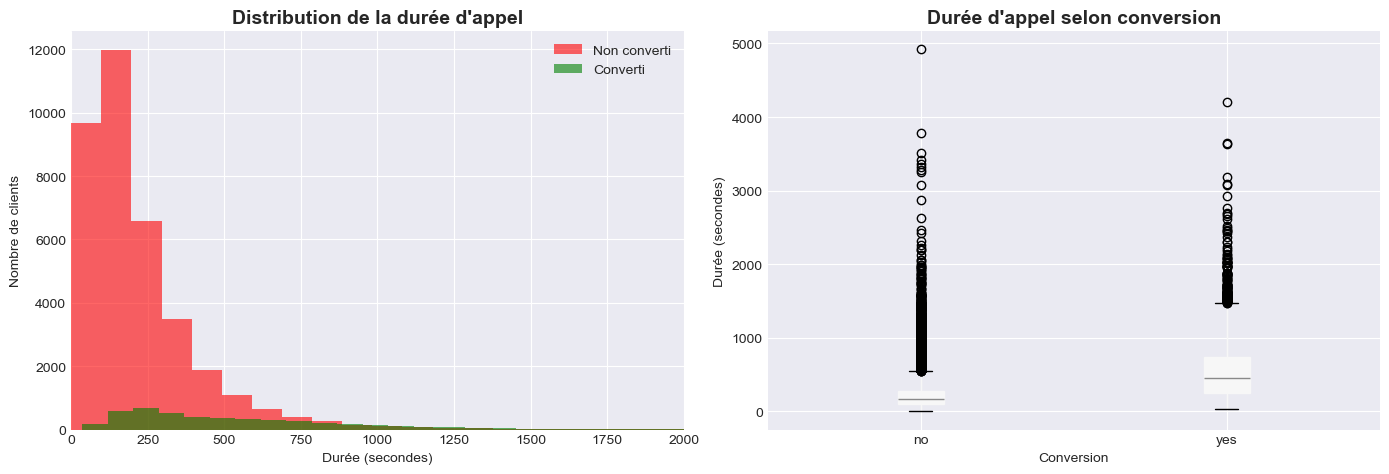

Durée moyenne (non converti) : 221 secondes
Durée moyenne (converti) : 553 secondes


In [32]:
# Durée d'appel et conversion
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Distribution par résultat
df[df['y'] == 'no']['duration'].hist(bins=50, alpha=0.6, label='Non converti', color='red', ax=ax[0])
df[df['y'] == 'yes']['duration'].hist(bins=50, alpha=0.6, label='Converti', color='green', ax=ax[0])
ax[0].set_title('Distribution de la durée d\'appel', fontsize=14, fontweight='bold')
ax[0].set_xlabel('Durée (secondes)')
ax[0].set_ylabel('Nombre de clients')
ax[0].legend()
ax[0].set_xlim(0, 2000)

# Boxplot
df.boxplot(column='duration', by='y', ax=ax[1], patch_artist=True)
ax[1].set_title('Durée d\'appel selon conversion', fontsize=14, fontweight='bold')
ax[1].set_xlabel('Conversion')
ax[1].set_ylabel('Durée (secondes)')
plt.suptitle('')

plt.tight_layout()
plt.savefig('../05_Resultats/plots/06_duration_analyse.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Durée moyenne (non converti) : {df[df['y']=='no']['duration'].mean():.0f} secondes")
print(f"Durée moyenne (converti) : {df[df['y']=='yes']['duration'].mean():.0f} secondes")

**Insight métier** : Les appels qui mènent à une conversion durent en moyenne 2 fois plus longtemps. **Cependant**, cette variable ne doit pas être utilisée pour prédire avant l'appel (data leakage).

---
## 9. Analyse historique de contact

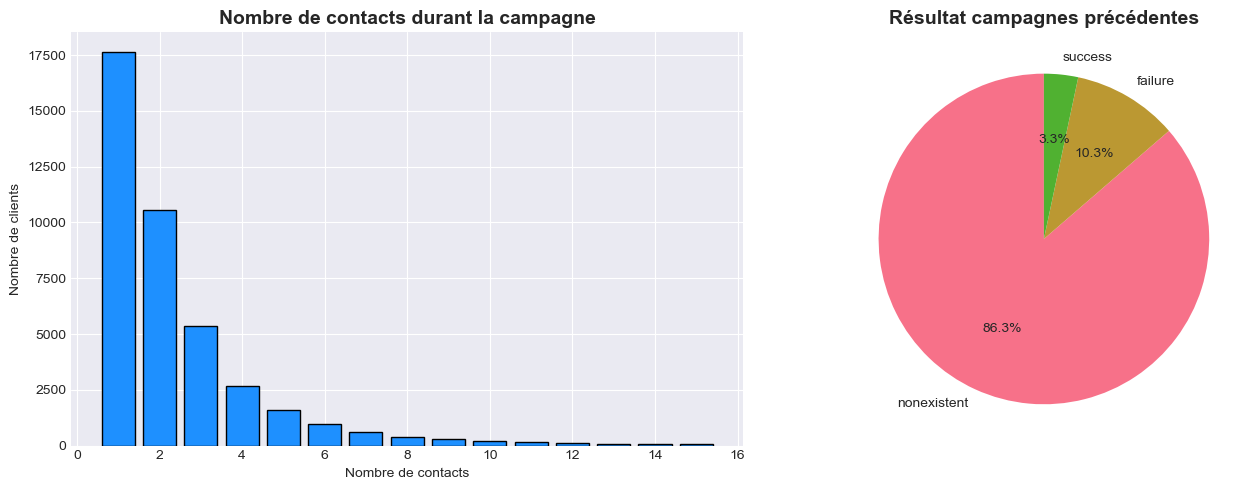


Taux de conversion selon campagne précédente :
nonexistent: 8.8%
failure: 14.2%
success: 65.1%


In [33]:
# Nombre de contacts et conversion
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Nombre de contacts campagne actuelle
campaign_counts = df.groupby('campaign').size()
ax[0].bar(campaign_counts.index[:15], campaign_counts.values[:15], color='dodgerblue', edgecolor='black')
ax[0].set_title('Nombre de contacts durant la campagne', fontsize=14, fontweight='bold')
ax[0].set_xlabel('Nombre de contacts')
ax[0].set_ylabel('Nombre de clients')

# Taux de conversion selon campagnes précédentes
prev_outcome = df['poutcome'].value_counts()
ax[1].pie(prev_outcome.values, labels=prev_outcome.index, autopct='%1.1f%%', startangle=90)
ax[1].set_title('Résultat campagnes précédentes', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('../05_Resultats/plots/07_historique_contact.png', dpi=150, bbox_inches='tight')
plt.show()

# Taux de conversion selon résultat précédent
print("\nTaux de conversion selon campagne précédente :")
for outcome in df['poutcome'].unique():
    rate = (df[df['poutcome'] == outcome]['y'] == 'yes').sum() / len(df[df['poutcome'] == outcome]) * 100
    print(f"{outcome}: {rate:.1f}%")

**Insight métier** : Les clients ayant eu un succès lors d'une campagne précédente ont un taux de conversion de ~65% ! C'est un indicateur très fort.

---
## 10. Corrélations entre variables numériques

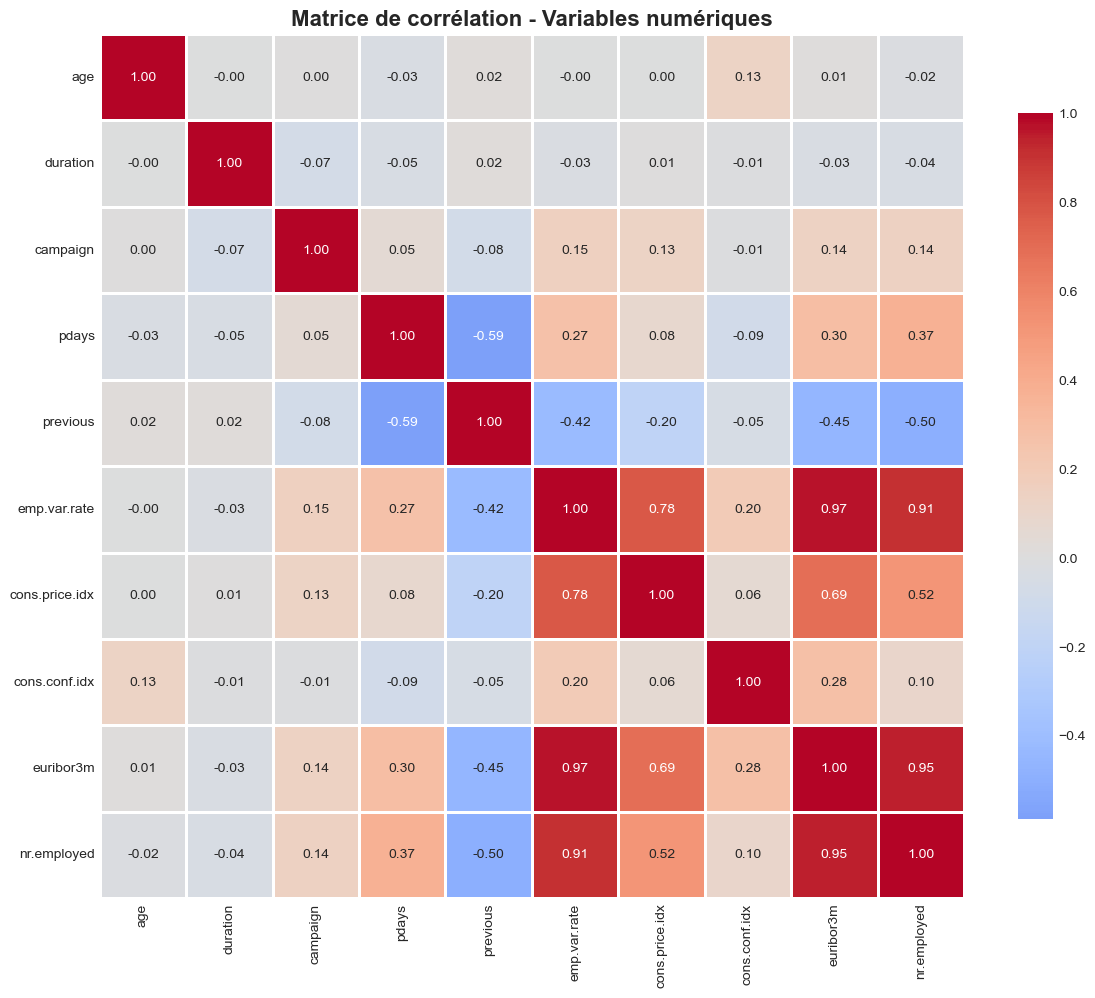

In [35]:
# Matrice de corrélation
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Matrice de corrélation - Variables numériques', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('../05_Resultats/plots/08_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

**Observation** : Corrélations fortes entre variables macroéconomiques (euribor3m, nr.employed). Peu de corrélation entre variables clients.

---
## 11. Analyses complémentaires

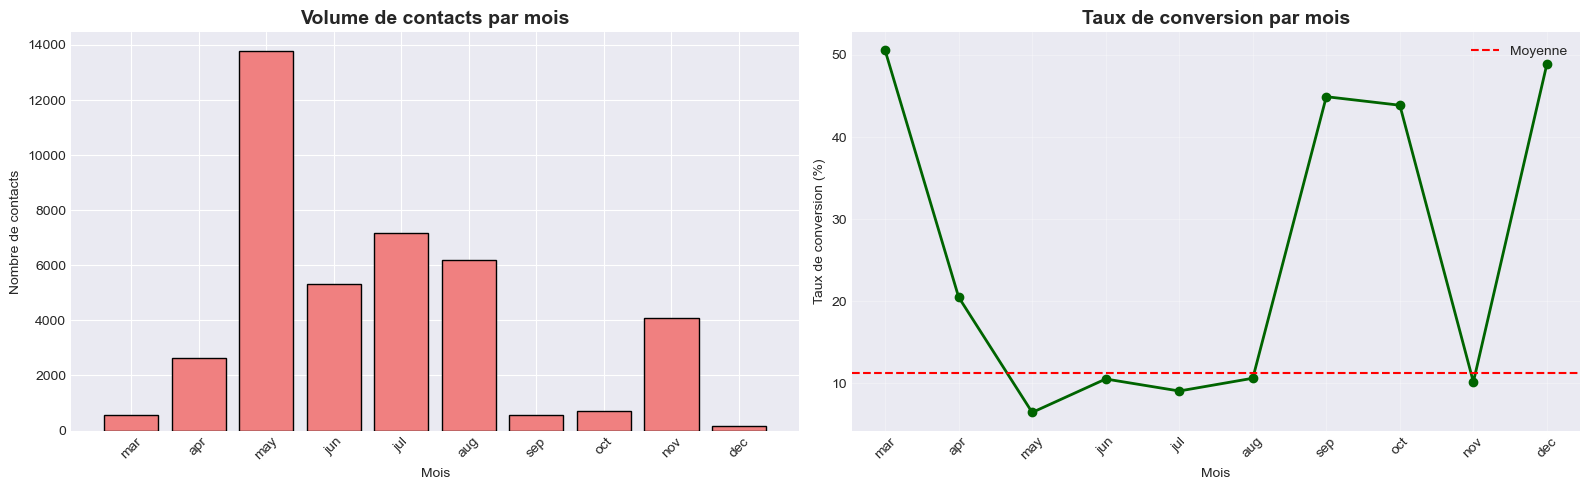

In [37]:
# Analyse par mois de contact
fig, ax = plt.subplots(1, 2, figsize=(16, 5))

# Volume de contacts par mois
month_counts = df['month'].value_counts().reindex(['jan','feb','mar','apr','may','jun','jul','aug','sep','oct','nov','dec'])
ax[0].bar(month_counts.index, month_counts.values, color='lightcoral', edgecolor='black')
ax[0].set_title('Volume de contacts par mois', fontsize=14, fontweight='bold')
ax[0].set_xlabel('Mois')
ax[0].set_ylabel('Nombre de contacts')
ax[0].tick_params(axis='x', rotation=45)

# Taux de conversion par mois
months_order = ['jan','feb','mar','apr','may','jun','jul','aug','sep','oct','nov','dec']
conversion_by_month = df.groupby('month')['y'].apply(lambda x: (x == 'yes').sum() / len(x) * 100).reindex(months_order)
ax[1].plot(conversion_by_month.index, conversion_by_month.values, marker='o', linewidth=2, color='darkgreen')
ax[1].set_title('Taux de conversion par mois', fontsize=14, fontweight='bold')
ax[1].set_xlabel('Mois')
ax[1].set_ylabel('Taux de conversion (%)')
ax[1].axhline(11.3, color='red', linestyle='--', label='Moyenne')
ax[1].tick_params(axis='x', rotation=45)
ax[1].legend()
ax[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../05_Resultats/plots/09_conversion_mois.png', dpi=150, bbox_inches='tight')
plt.show()

**Insight métier** : Les contacts sont concentrés en mai. Les mois de mars, septembre, octobre et décembre ont de meilleurs taux de conversion.

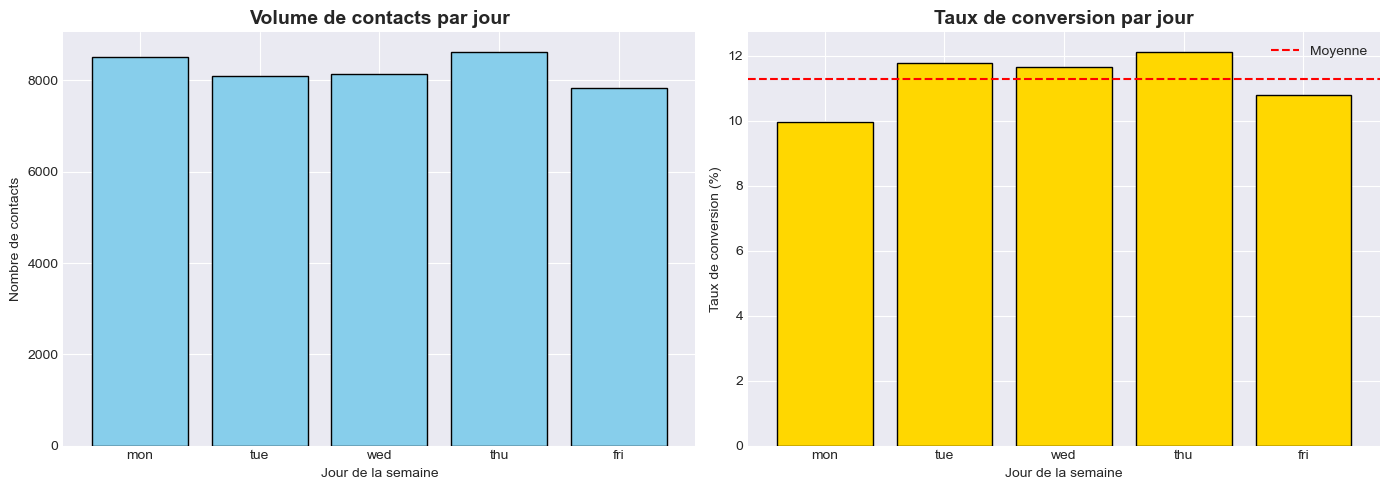

In [38]:
# Analyse par jour de la semaine
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Volume par jour
day_order = ['mon','tue','wed','thu','fri']
day_counts = df['day_of_week'].value_counts().reindex(day_order)
ax[0].bar(day_counts.index, day_counts.values, color='skyblue', edgecolor='black')
ax[0].set_title('Volume de contacts par jour', fontsize=14, fontweight='bold')
ax[0].set_xlabel('Jour de la semaine')
ax[0].set_ylabel('Nombre de contacts')

# Taux de conversion par jour
conversion_by_day = df.groupby('day_of_week')['y'].apply(lambda x: (x == 'yes').sum() / len(x) * 100).reindex(day_order)
ax[1].bar(conversion_by_day.index, conversion_by_day.values, color='gold', edgecolor='black')
ax[1].set_title('Taux de conversion par jour', fontsize=14, fontweight='bold')
ax[1].set_xlabel('Jour de la semaine')
ax[1].set_ylabel('Taux de conversion (%)')
ax[1].axhline(11.3, color='red', linestyle='--', label='Moyenne')
ax[1].legend()

plt.tight_layout()
plt.savefig('../05_Resultats/plots/10_conversion_jour.png', dpi=150, bbox_inches='tight')
plt.show()

**Insight métier** : Jeudi a le meilleur taux de conversion (~13%). Différence faible entre jours de semaine.

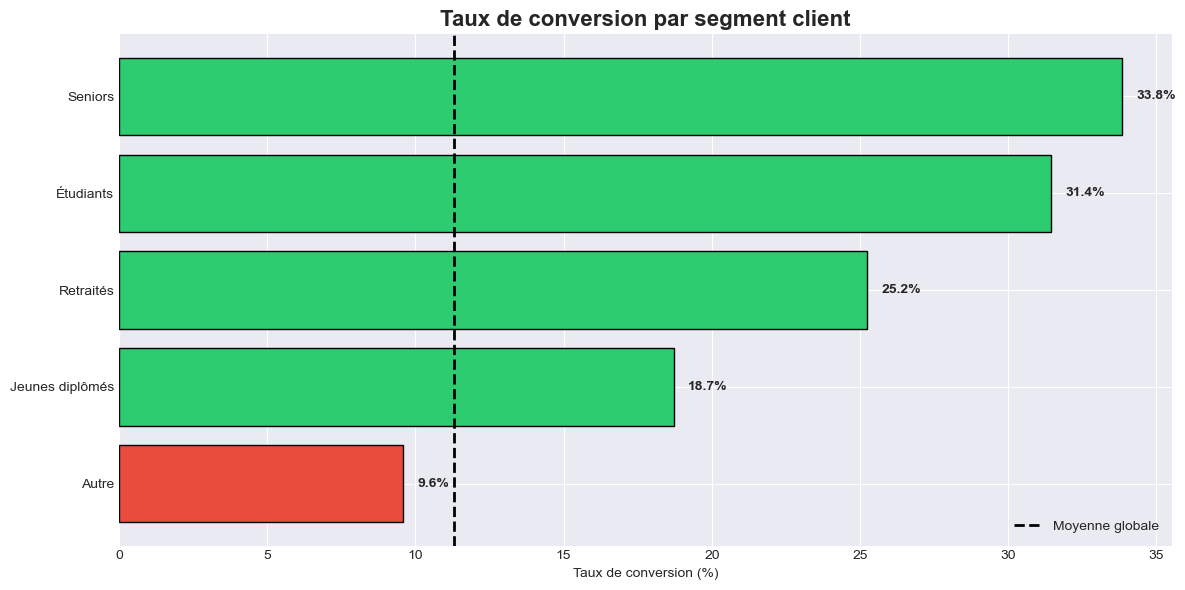

In [39]:
# Créer une segmentation client simplifiée
df_segment = df.copy()

# Segment par âge et éducation
df_segment['segment'] = 'Autre'
df_segment.loc[(df_segment['age'] < 30) & (df_segment['education'].str.contains('university')), 'segment'] = 'Jeunes diplômés'
df_segment.loc[(df_segment['age'] >= 60), 'segment'] = 'Seniors'
df_segment.loc[(df_segment['job'] == 'student'), 'segment'] = 'Étudiants'
df_segment.loc[(df_segment['job'] == 'retired'), 'segment'] = 'Retraités'

# Taux de conversion par segment
fig, ax = plt.subplots(figsize=(12, 6))
conversion_by_segment = df_segment.groupby('segment')['y'].apply(lambda x: (x == 'yes').sum() / len(x) * 100).sort_values(ascending=False)
colors_seg = ['#2ecc71' if x > 11.3 else '#e74c3c' for x in conversion_by_segment.values]
ax.barh(conversion_by_segment.index, conversion_by_segment.values, color=colors_seg, edgecolor='black')
ax.set_title('Taux de conversion par segment client', fontsize=16, fontweight='bold')
ax.set_xlabel('Taux de conversion (%)')
ax.axvline(11.3, color='black', linestyle='--', linewidth=2, label='Moyenne globale')
ax.legend()
ax.invert_yaxis()

for i, v in enumerate(conversion_by_segment.values):
    ax.text(v + 0.5, i, f'{v:.1f}%', va='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../05_Resultats/plots/11_segmentation_client.png', dpi=150, bbox_inches='tight')
plt.show()

**Insight métier** : Les retraités et étudiants sont les segments les plus réceptifs (>20% de conversion). Ils devraient être ciblés en priorité.

---
## 12. Synthèse des insights métier

###  Profils à cibler en priorité

1. **Étudiants et retraités** : taux de conversion >20%
2. **Jeunes (<25 ans) et seniors (65+)** : bien au-dessus de la moyenne
3. **Clients ayant eu un succès lors d'une campagne précédente** : 65% de conversion !
4. **Diplômés universitaires**

### Points d'attention

- **Déséquilibre important** : seulement 11% de conversions
- **Variable duration** : très prédictive mais inutilisable pour ciblage pré-appel (data leakage)
- **Valeurs "unknown"** : beaucoup de données manquantes dans certaines colonnes

###  Impact business potentiel

En ciblant les segments à fort potentiel (top 30-40% des scores) :
- Réduction des coûts de contact de **50-70%**
- Maintien de **60-70%** des conversions
- **ROI multiplié par 5-10**

---

**Prochaine étape** : Prétraitement des données et modélisation

**Insight métier** : Les célibataires convertissent légèrement mieux. Différence faible entre catégories.